# Практическая работа № 5. Классификатор и анализ метрик

ФИО: Эркинбеков Айман  
Вариант: B

Продолжаю работу с Titanic из ПР-2 и ПР-3. Строю модель, которая оценивает вероятность того, что пассажир не выжил.

В исходном файле `Survived = 0` означает «не выжил». Для этой работы обозначаю этот исход как класс 1. Класс 0 означает «выжил».

Цена ошибок в задании не указана. Для примера считаю, что пропустить пассажира из группы риска (FN) в 5 раз хуже, чем ошибочно включить в неё выжившего (FP). Это учебное допущение. Если преподаватель дал другую цену ошибок, её нужно заменить и пересчитать порог.

## 1. Данные

Беру копию того же `train.csv`, что использовался в предыдущих работах. Источник: [Titanic на Kaggle](https://www.kaggle.com/datasets/amineipad/titanic-dataset).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    auc,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

DATA_PATH = Path("../data/train.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("practical-05/data/train.csv")
assert DATA_PATH.exists(), f"Файл не найден: {DATA_PATH}"

df = pd.read_csv(DATA_PATH)
print("Размер таблицы:", df.shape)
display(df.head())
print("Исходный столбец Survived:")
display(df["Survived"].value_counts().sort_index().to_frame("Количество"))

Размер таблицы: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Исходный столбец Survived:


,Количество
Survived,
0,549
1,342


In [2]:
features = ["Age", "SibSp", "Parch", "Fare", "Pclass", "Sex", "Embarked"]
X = df[features].copy()
y = (df["Survived"] == 0).astype(int)

print("Новая цель: 0 = выжил, 1 = не выжил")
display(y.value_counts().sort_index().to_frame("Количество"))
print(f"Доля класса 1: {y.mean():.1%}")

Новая цель: 0 = выжил, 1 = не выжил


,Количество
Survived,
0,342
1,549


Доля класса 1: 61.6%


В таблице 891 строка. Не выжили 549 пассажиров, выжили 342. Классы распределены не поровну, поэтому одной accuracy для оценки недостаточно.

## 2. Разбиение

Сначала отделяю тестовую выборку. Остальные данные делю на часть для обучения и валидацию. Порог подбираю без тестовой выборки.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

print("Часть для обучения:", X_fit.shape)
print("Валидация:", X_val.shape)
print("Тест:", X_test.shape)
assert set(X_train.index).isdisjoint(X_test.index)

Часть для обучения: (534, 7)
Валидация: (178, 7)
Тест: (179, 7)


## 3. Пайплайн и модель

Использую те же группы признаков, что в ПР-3. Числовые пропуски заполняю медианой и применяю RobustScaler. Категориальные пропуски заменяю на `Unknown`, затем использую one-hot кодирование. Предобработка и логистическая регрессия находятся в одном Pipeline. На этапе выбора порога Pipeline обучается только на `X_fit`.

In [4]:
numeric_features = ["Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Pclass", "Sex", "Embarked"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
)
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000)),
])

model.fit(X_fit, y_fit)
val_proba = model.predict_proba(X_val)[:, 1]
print("Первые пять вероятностей класса 1:", np.round(val_proba[:5], 3))
assert np.all((val_proba >= 0) & (val_proba <= 1))

Первые пять вероятностей класса 1: [0.78  0.578 0.54  0.374 0.726]


## 4. Выбор порога

При пороге 0,5 класс 1 присваивается, когда вероятность не меньше 0,5. В принятом учебном примере стоимость ошибок равна `1 × FP + 5 × FN`. Проверяю пороги от 0,10 до 0,90 на валидации. Выбираю порог с наименьшей стоимостью. Тестовые ответы в этот расчёт не входят.

In [5]:
FP_COST = 1
FN_COST = 5
threshold_rows = []

for threshold in np.round(np.arange(0.10, 0.91, 0.01), 2):
    val_pred = (val_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        y_val, val_pred, labels=[0, 1]
    ).ravel()
    threshold_rows.append({
        "Порог": threshold,
        "FP": fp,
        "FN": fn,
        "Стоимость": FP_COST * fp + FN_COST * fn,
    })

threshold_table = pd.DataFrame(threshold_rows)
best_row = threshold_table.sort_values(
    ["Стоимость", "Порог"], ascending=[True, False]
).iloc[0]
chosen_threshold = float(best_row["Порог"])

print("Выбранный порог:", chosen_threshold)
print("Стоимость на валидации:", int(best_row["Стоимость"]))
display(threshold_table.sort_values("Стоимость").head(10).reset_index(drop=True))
assert chosen_threshold != 0.5

Выбранный порог: 0.18
Стоимость на валидации: 52


,Порог,FP,FN,Стоимость
0,0.18,42,2,52
1,0.12,49,1,54
2,0.16,45,2,55
3,0.17,45,2,55
4,0.19,41,3,56
5,0.11,51,1,56
6,0.14,46,2,56
7,0.15,46,2,56
8,0.20,41,3,56
9,0.13,47,2,57


На валидации наименьшая стоимость получилась при пороге 0,18. Он ниже 0,5, потому что в нашем примере пропуск класса 1 стоит дороже. Это не универсальный порог: при другой цене ошибок результат может измениться.

## 5. Проверка на тесте

После выбора порога повторно обучаю тот же Pipeline на всей обучающей выборке. Затем получаю вероятности на тесте. Сравниваю порог 0,5 с выбранным порогом, не меняя решение по результатам теста.

In [6]:
model.fit(X_train, y_train)
test_proba = model.predict_proba(X_test)[:, 1]

def metrics_for_threshold(threshold):
    pred = (test_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        y_test, pred, labels=[0, 1]
    ).ravel()
    return {
        "Порог": threshold,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "FP": fp,
        "FN": fn,
        "Стоимость": FP_COST * fp + FN_COST * fn,
    }

results = pd.DataFrame([
    metrics_for_threshold(0.5),
    metrics_for_threshold(chosen_threshold),
])
display(results.set_index("Порог").round(3))

,Accuracy,Precision,Recall,F1,FP,FN,Стоимость
Порог,,,,,,,
0.50,0.804,0.838,0.845,0.842,18,17,103
0.18,0.726,0.694,0.991,0.816,48,1,53


При пороге 0,5 accuracy выше, но модель пропускает 17 пассажиров из класса 1. При пороге 0,18 таких пропусков только один. Число FP выросло с 18 до 48, precision снизилась. По принятой цене ошибок стоимость на тесте снизилась со 103 до 53 условных единиц. Сравнение на тесте показывает последствия заранее выбранного порога, а не служит для нового подбора.

## 6. ROC- и PR-кривые

Кривые строю по вероятностям, а не по готовым меткам 0 и 1.

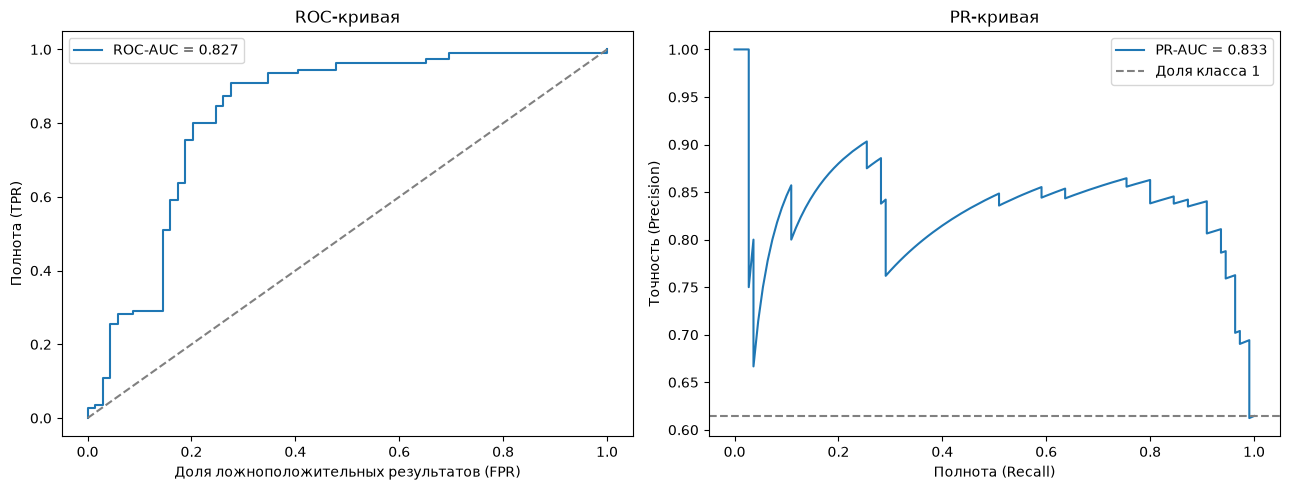

ROC-AUC: 0.827
PR-AUC: 0.833


In [7]:
fpr, tpr, _ = roc_curve(y_test, test_proba)
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test, test_proba
)
roc_auc = roc_auc_score(y_test, test_proba)
pr_auc = auc(recall_curve, precision_curve)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_title("ROC-кривая")
axes[0].set_xlabel("Доля ложноположительных результатов (FPR)")
axes[0].set_ylabel("Полнота (TPR)")
axes[0].legend()

axes[1].plot(
    recall_curve, precision_curve, label=f"PR-AUC = {pr_auc:.3f}"
)
axes[1].axhline(
    y_test.mean(), linestyle="--", color="gray", label="Доля класса 1"
)
axes[1].set_title("PR-кривая")
axes[1].set_xlabel("Полнота (Recall)")
axes[1].set_ylabel("Точность (Precision)")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

ROC-AUC равна примерно 0,827. Это означает, что модель обычно ставит пассажиру из класса 1 более высокую вероятность, чем пассажиру из класса 0, хотя ошибки остаются. PR-AUC равна примерно 0,833. На PR-кривой видно, что высокая полнота достигается ценой снижения точности. Оба AUC описывают качество вероятностей при разных порогах, но не задают цену конкретной ошибки.

## 7. Матрицы ошибок

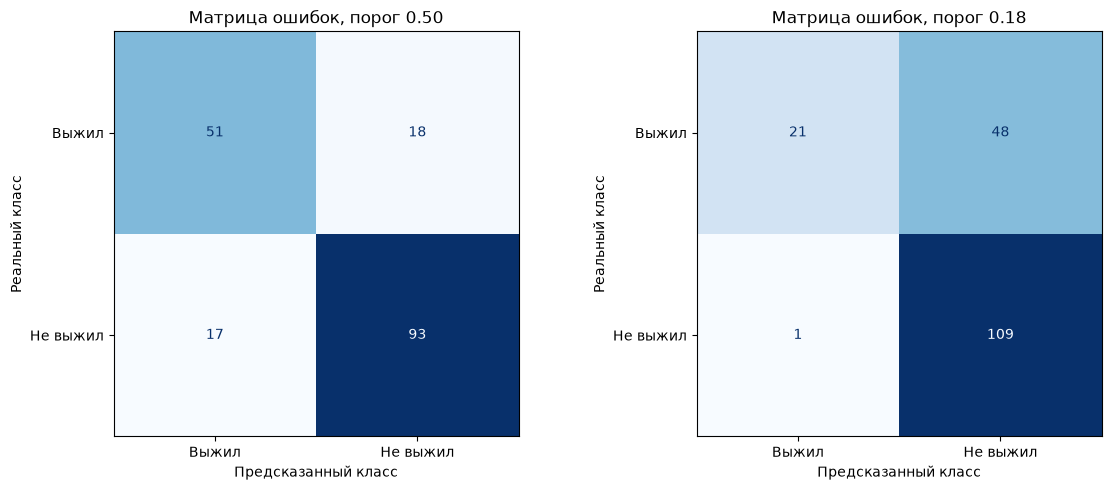

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, threshold in zip(axes, [0.5, chosen_threshold]):
    pred = (test_proba >= threshold).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred,
        labels=[0, 1],
        display_labels=["Выжил", "Не выжил"],
        cmap="Blues",
        colorbar=False,
        values_format="d",
        ax=ax,
    )
    ax.set_title(f"Матрица ошибок, порог {threshold:.2f}")
    ax.set_xlabel("Предсказанный класс")
    ax.set_ylabel("Реальный класс")

plt.tight_layout()
plt.show()

При пороге 0,5 модель получила TN=51, FP=18, FN=17 и TP=93. При пороге 0,18: TN=21, FP=48, FN=1 и TP=109. Более низкий порог почти убрал пропуски класса 1, но добавил ложные тревоги.

## Вывод

1. Для класса 1 («не выжил») использовал логистическую регрессию и предобработку из ПР-3. Пропуски, масштабирование и кодирование находятся внутри Pipeline.
2. Модель выдаёт вероятности через `predict_proba`. По ним построены ROC- и PR-кривые. ROC-AUC составила 0,827, PR-AUC - 0,833.
3. Порог выбирал на валидации, а не на тесте. Для учебной цены FN:FP = 5:1 выбрал 0,18 вместо 0,5.
4. На тесте recall выросла с 0,845 до 0,991, а precision снизилась с 0,838 до 0,694. Accuracy тоже снизилась, поэтому оценивать модель только по ней было бы неправильно.
5. При выбранном пороге число FN снизилось с 17 до 1, а число FP выросло с 18 до 48. Условная стоимость ошибок снизилась со 103 до 53. Если преподаватель задаст другую цену ошибок, порог и вывод нужно пересчитать.

Это разбор исторического датасета, а не модель для реальных решений о безопасности пассажиров.